# IY021 – SimCLR Embeddings + SVM on Experimental Data

**Goal:** Use frozen SimCLR-trained transformer backbones to encode experimental Msn2-mCherry time series, then classify the embeddings with an RBF SVM across glucose environments.

**Models evaluated (28 checkpoints):**
- IY017: instance-norm models, various batch sizes and d_model (D8, D16, D128)
- IY022: single-dataset models with global / joint / batch-wise normalisation
- IY023: mixed-dataset (all 4 sources) models with batch-wise normalisation

---

### TF structure of the experiments

Each experiment contains multiple yeast strains ("groups"), each expressing **Msn2-mCherry** alongside a strain-specific **GFP-TF**. Classifications are only meaningful when comparing the **same strain** under different glucose conditions.

| Experiment | Glucose | group 1344 (Cat8-GFP) | group 1346 (Nrg1-GFP) | group 1347 (Rtg1-GFP) | Other groups |
|---|---|---|---|---|---|
| 19316 | **2%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 19554 | 0.01% | — | — | — | 900=Mig1/Msn2, 756/903=unknown |
| 19566 | **0.1%** | ⚠️ TF uncertain | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 20213 | **0.01%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |

**Exclusions (with reason):**
- **19554 entirely**: Mig1-GFP strain (group 900) not comparable to Nrg1/Rtg1/Cat8; groups 756/903 unidentified
- **19566 / group 1344**: TF identity ambiguous (absent from OMERO metadata for this experiment)

**Included for 3-way classification (2% vs 0.1% vs 0.01%):**  
Groups **1346 (Nrg1)** and **1347 (Rtg1)** — the only strains present across all 3 glucose conditions.

**Key difference from IY022/IY023 downstream notebooks:**  
Those notebooks encode *pairs* and use `|z1−z2|` for same/different verification.  
Here we encode *individual* series via `backbone.encode()` and classify embeddings directly (multi-class task).

In [1]:
import re
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
EXP_DIR  = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]

RANDOM_STATE = 42
IY021_DIR = EXP_DIR / "EXP-26-IY021"
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Experimental Data & Assign Labels

In [2]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}

print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))
    else:
        print("  (no TF metadata)")

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [3]:
FILE_REGISTRY = {
    # --- 2% glucose (label 0) ---
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series":
        (0, "2%",   "Nrg1", "Msn2"),
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series":
        (0, "2%",   "Rtg1", "Msn2"),
    # --- 0.1% glucose (label 1) ---
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series":
        (1, "0.1%", "Nrg1", "Msn2"),
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series":
        (1, "0.1%", "Rtg1", "Msn2"),
    # --- 0.01% glucose (label 2) ---
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series":
        (2, "0.01%", "Nrg1", "Msn2"),
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series":
        (2, "0.01%", "Rtg1", "Msn2"),
}
# Exclusions (with reason):
#   19554 entirely  – Mig1-GFP (group 900) not comparable; groups 756/903 TF unknown
#   19566/group1344 – TF identity ambiguous (absent from OMERO metadata)
#   Cat8 (group1344 in 19316/20213) – only present in 2 of 3 conditions; excluded for balance

label_names = {0: "2% glucose", 1: "0.1% glucose", 2: "0.01% glucose"}
META_COLS   = ["id", "group", "experiment"]

all_X, all_y, all_strain = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem
    if stem not in FILE_REGISTRY:
        continue
    glucose_label, glucose_pct, gfp_tf, mcherry_tf = FILE_REGISTRY[stem]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_X.append(ts)
    all_y.extend([glucose_label] * len(ts))
    all_strain.extend([gfp_tf] * len(ts))
    print(f"  Loaded: {gfp_tf}-GFP/Msn2-mCherry @ {glucose_pct} glc  "
          f"({ts.shape[0]} cells × {ts.shape[1]} tp)")

# Files have different numbers of timepoints — truncate to the shortest
min_tp = min(ts.shape[1] for ts in all_X)
print(f"\nTruncating all series to {min_tp} timepoints (shortest file)")
all_X = [ts[:, :min_tp] for ts in all_X]

X_raw   = np.vstack(all_X)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    mask = y == lbl
    strain_counts = {s: int(np.sum(strains[mask] == s)) for s in np.unique(strains[mask])}
    print(f"  {lbl}: {name:15s} → {mask.sum():4d} cells  {strain_counts}")

  Loaded: Nrg1-GFP/Msn2-mCherry @ 2% glc  (84 cells × 128 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 2% glc  (78 cells × 126 tp)
  Loaded: Nrg1-GFP/Msn2-mCherry @ 0.1% glc  (231 cells × 135 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 0.1% glc  (200 cells × 117 tp)
  Loaded: Nrg1-GFP/Msn2-mCherry @ 0.01% glc  (231 cells × 105 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 0.01% glc  (275 cells × 89 tp)

Truncating all series to 89 timepoints (shortest file)
Dataset: 1099 cells × 89 timepoints
  0: 2% glucose      →  162 cells  {np.str_('Nrg1'): 84, np.str_('Rtg1'): 78}
  1: 0.1% glucose    →  431 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 200}
  2: 0.01% glucose   →  506 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 275}


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_trace_overview.png


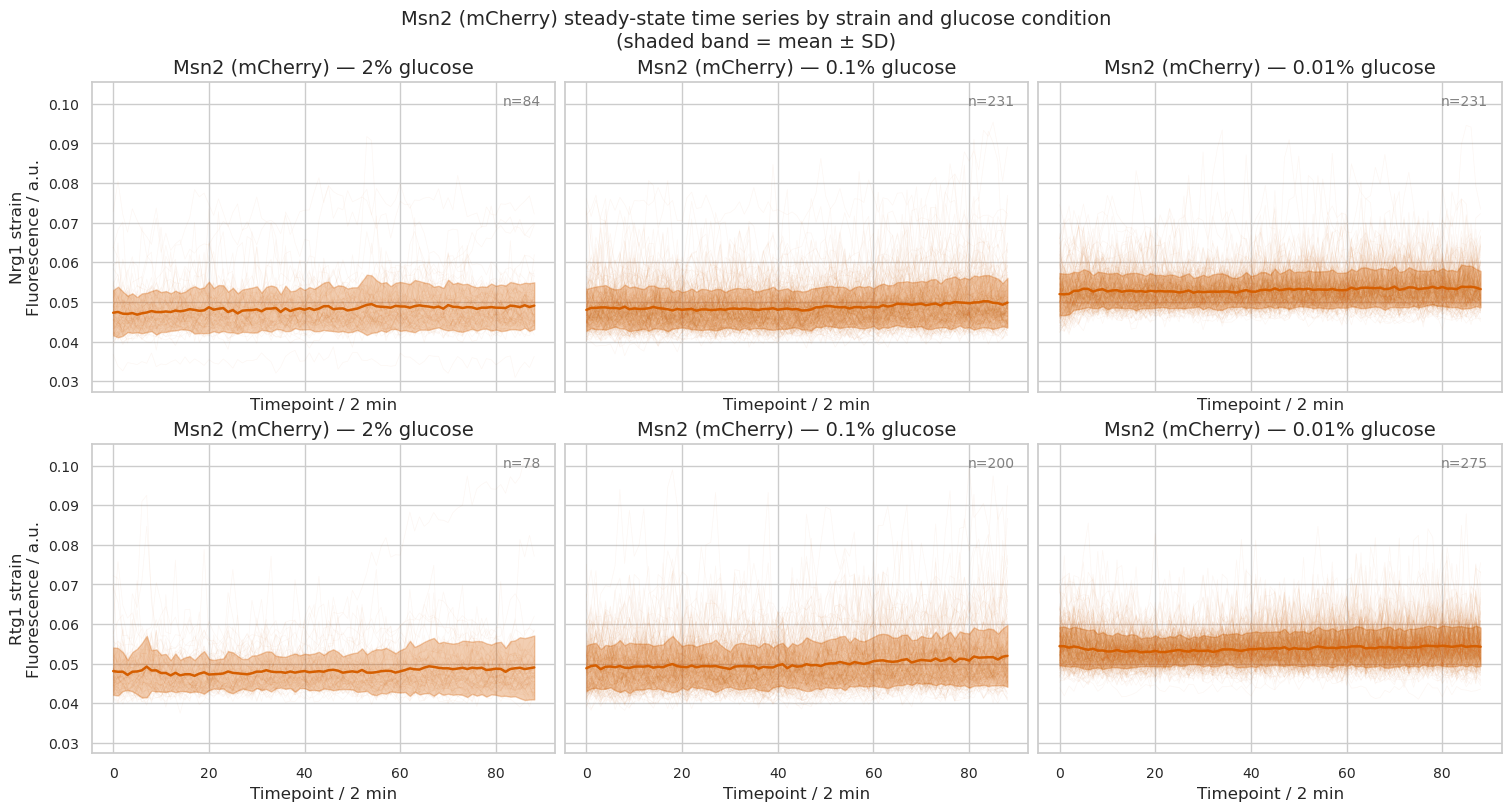

In [4]:
palette  = sns.color_palette("colorblind")
ch_color = palette[3]  # reddish — mCherry

tfs        = ["Nrg1", "Rtg1"]
conditions = sorted(label_names.keys())
n_tp       = X_raw.shape[1]
t_axis     = np.arange(n_tp)
n_rows, n_cols = len(tfs), len(conditions)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True, sharex=True,
    constrained_layout=True,
)

for row, tf in enumerate(tfs):
    for col, lbl in enumerate(conditions):
        ax    = axes[row][col]
        mask  = (y == lbl) & (strains == tf)
        X_sub = X_raw[mask]

        for trace in X_sub:
            ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)

        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            sd   = np.nanstd(X_sub, axis=0)
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sd, mean + sd, color=ch_color, alpha=0.3)

        ax.set_title(f"Msn2 (mCherry) — {label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=10, color="gray")

fig.suptitle(
    "Msn2 (mCherry) steady-state time series by strain and glucose condition\n"
    "(shaded band = mean ± SD)",
    fontsize=14,
)
fig_path = IY021_DIR / "IY021_mCherry_trace_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 2. Preprocessing: NaN Fill, Balance & Normalize

In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from utils.processing.imputation import fill_nans

X_clean = fill_nans(X_raw)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])
X_bal = X_clean[bal_idx]
y_bal = y[bal_idx]

# Train / test split first, then normalise using train statistics only
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Balanced: {X_bal.shape[0]} cells  |  class counts: {np.bincount(y_bal)}")
print(f"Train {X_train.shape[0]}  |  Test {X_test.shape[0]}")
print("Normalisation: batch-wise z-score fit on train, applied to test")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mcherry_simclr_balanced_class_traces.png


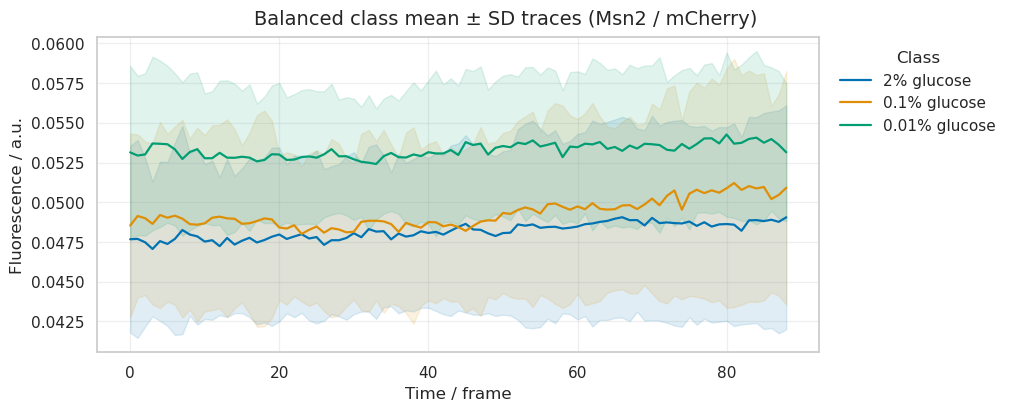

In [6]:
class_names_bal = [label_names[i] for i in sorted(label_names)]
palette = sns.color_palette("colorblind", n_colors=len(class_names_bal))
n_tp = X_bal.shape[1]

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
for lbl, class_name in enumerate(class_names_bal):
    mask = y_bal == lbl
    mean = X_bal[mask].mean(axis=0)
    sd = X_bal[mask].std(axis=0, ddof=1)
    color = palette[lbl]
    ax.plot(np.arange(n_tp), mean, label=class_name, color=color, linewidth=1.6)
    ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=color, alpha=0.12)

ax.set_xlabel("Time / frame")
ax.set_ylabel("Fluorescence / a.u.")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced class mean ± SD traces (Msn2 / mCherry)", fontsize=14)
fig_path = IY021_DIR / "IY021_mcherry_simclr_balanced_class_traces.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()


## 3. SimCLR Model Registry & Helper Functions

In [ ]:
from utils.embeddings import make_checkpoint_short_label, make_unique_checkpoint_label
from utils.embeddings import parse_arch_from_name, load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_checkpoint_short_label(p, NORM_OVERRIDES),
            "label": make_unique_checkpoint_label(p, len(MODEL_REGISTRY), NORM_OVERRIDES),
            "experiment": d,
        })

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch_from_name(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")

def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    """Extract embeddings → StandardScale → SVM (RBF) → (accuracy, y_pred)."""
    Z_tr = encode_channel(model, X_tr, device)
    Z_te = encode_channel(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

## 4. Run All Models

In [8]:
result_rows = []
predictions = {}  # {str(ckpt_path): y_pred}

for row in MODEL_REGISTRY:
    ckpt_path = row["path"]
    label = row["label"]
    print(f"\n{'=' * 70}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")
    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm(model, X_train, X_test, y_train, y_test, DEVICE)
        predictions[str(ckpt_path)] = y_pred
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": acc,
            "status": "ok",
            "error": "",
        })
        print(f"  Accuracy: {acc:.4f}")
    except Exception as exc:
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": np.nan,
            "status": "failed",
            "error": str(exc),
        })
        print(f"  FAILED: {exc}")

results_df = pd.DataFrame(result_rows).sort_values("accuracy", ascending=False, na_position="last").reset_index(drop=True)
results_path = IY021_DIR / "IY021_mCherry_simclr_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved: {results_path}")
display(results_df.head(12))


Model: IY017-inst b100 D128 #00
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth


  Accuracy: 0.5510

Model: IY017-inst b100 D128 #01
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.5816

Model: IY017-inst b1024 D16 164413
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.6327

Model: IY017-inst b1024 D16 061239
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.6327

Model: IY017-inst b128 D16 151037
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.6224

Model: IY017-inst b16 D16 #05
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.6633

Model: IY017-inst b16 D16 #06
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.4796

Model: IY017-inst b2048 D16 162432
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.7041

Model: IY017-inst b256 D16 154425
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.6327

Model: IY017-inst b32 D128 #09
  IY017_simCLR_b32_lr0.01_L2_H4_D128_model.pth
  Accur

,label,short_label,experiment,checkpoint,checkpoint_name,accuracy,status,error
0,IY023-batch b64 D8 120151,IY023-batch b64 D8,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D8_batch-w...,0.724490,ok,
1,IY023-batch b1024 D16 183509,IY023-batch b1024 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b1024_lr0.01_L2_H4_D16_batc...,0.724490,ok,
2,IY022-batch b64 D16 082200,IY022-batch b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_batch-wise_2...,0.704082,ok,
3,IY017-inst b4096 D16 140729,IY017-inst b4096 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260221_1...,0.704082,ok,
4,IY017-inst b2048 D16 162432,IY017-inst b2048 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_1...,0.704082,ok,
5,IY024-batch b64 D8 203126,IY024-batch b64 D8,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.693878,ok,
6,IY023-batch b64 D16 104312,IY023-batch b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_batch-...,0.693878,ok,
7,IY017-inst b64 D16 100838,IY017-inst b64 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b64_lr0.01_L2_H4_D16_20260216_100...,0.683673,ok,
8,IY023-global b512 D16 170227,IY023-global b512 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b512_lr0.01_L2_H4_D16_globa...,0.683673,ok,
9,IY023-global b64 D16 130449,IY023-global b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global...,0.673469,ok,


## 5. Results Visualisation

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_simclr_results.png


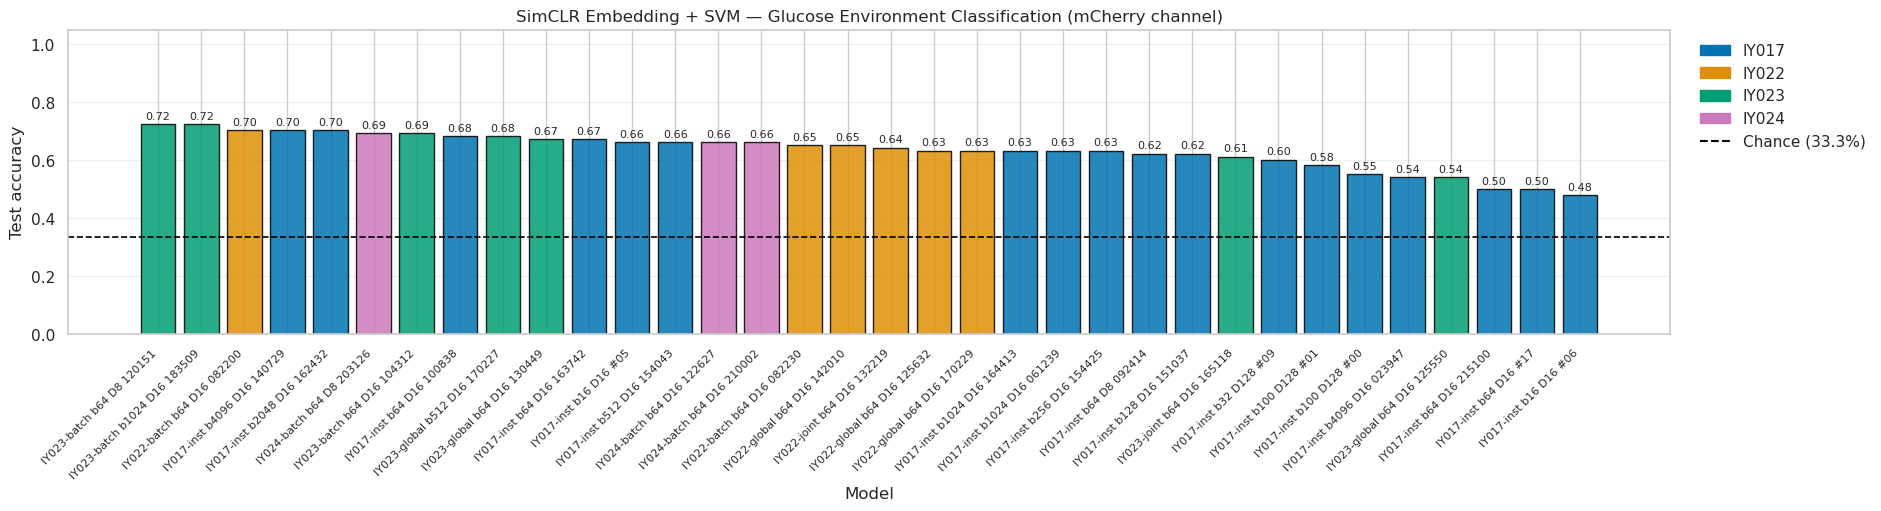

Best model: IY023-batch b64 D8 120151 (0.7245)
Checkpoint: IY023_simCLR_mixed_b64_lr0.01_L2_H4_D8_batch-wise_20260416_120151_model.pth
Chance: 0.3333


In [9]:
valid_results = results_df[results_df["status"] == "ok"].copy()
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)
palette = sns.color_palette("colorblind")

color_map = {
    "EXP-26-IY017": palette[0],
    "EXP-26-IY022": palette[1],
    "EXP-26-IY023": palette[2],
    "EXP-26-IY024": palette[4],
}
bar_colors = [color_map.get(exp, palette[7]) for exp in valid_results["experiment"]]

fig, ax = plt.subplots(figsize=(max(14, len(valid_results) * 0.55), 5), constrained_layout=True)
bars = ax.bar(range(len(valid_results)), valid_results["accuracy"], color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
ax.set_xticks(range(len(valid_results)))
ax.set_xticklabels(valid_results["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_title("SimCLR Embedding + SVM — Glucose Environment Classification (mCherry channel)")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, valid_results["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

legend_handles = [
    Patch(color=palette[0], label="IY017"),
    Patch(color=palette[1], label="IY022"),
    Patch(color=palette[2], label="IY023"),
    Patch(color=palette[4], label="IY024"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.1%})"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

fig_path = IY021_DIR / "IY021_mCherry_simclr_results.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

best = valid_results.iloc[0]
print(f"Best model: {best['label']} ({best['accuracy']:.4f})")
print(f"Checkpoint: {best['checkpoint_name']}")
print(f"Chance: {chance:.4f}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_simclr_top_confusion_matrices.png


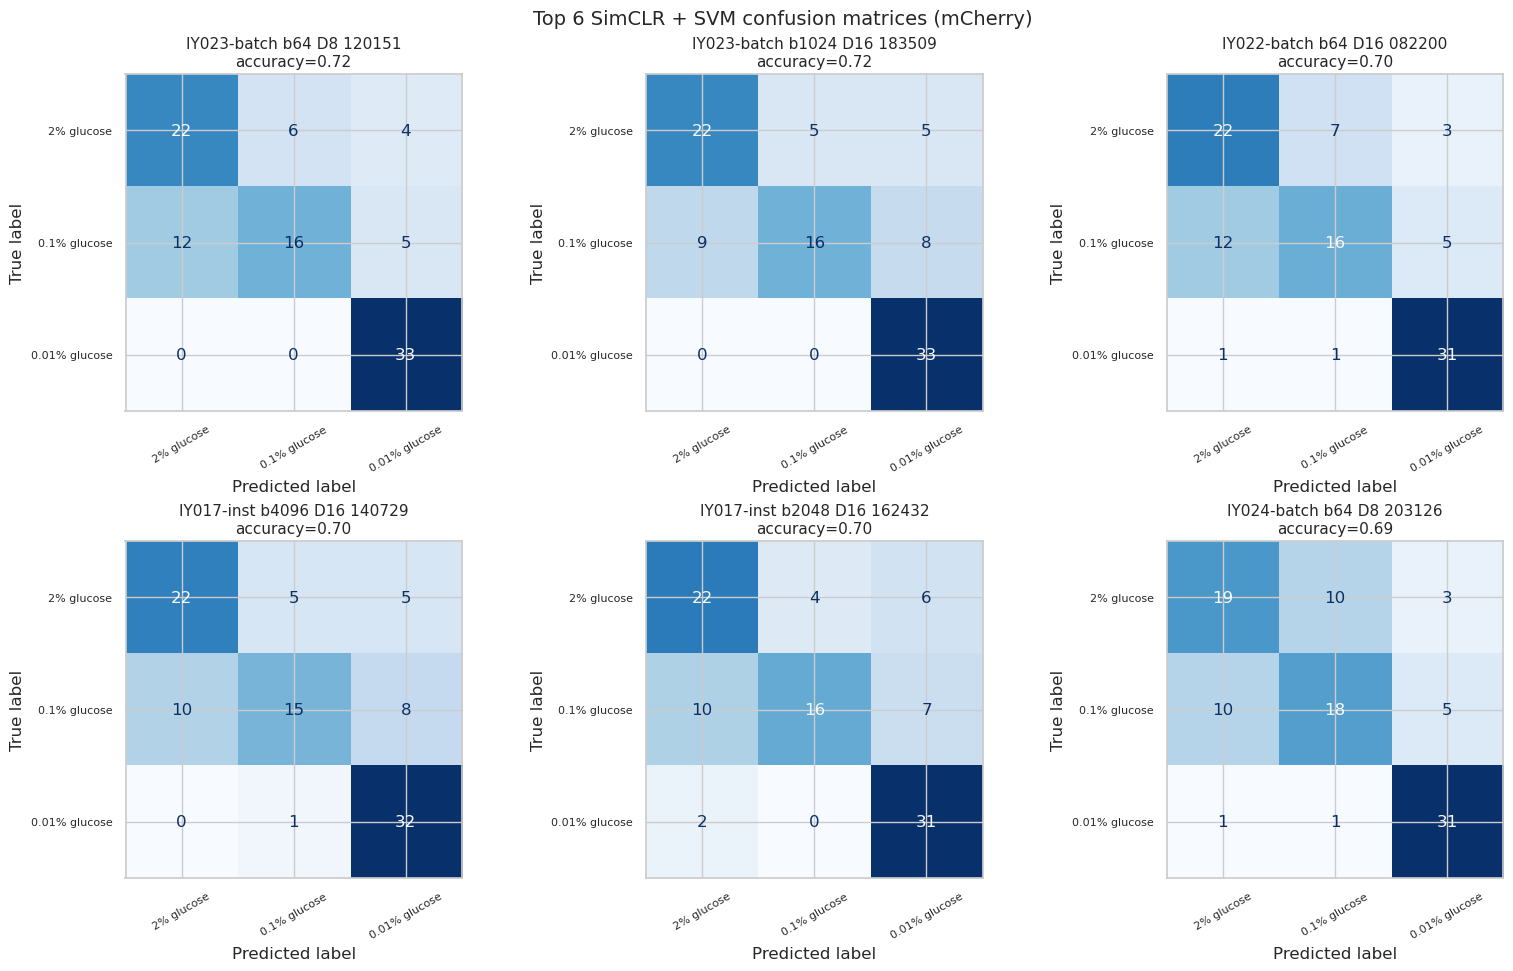

In [10]:
TOP_N_CONFUSION = 6
top_results = valid_results.head(TOP_N_CONFUSION)
ncols = min(3, len(top_results))
nrows = int(np.ceil(len(top_results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_results.iterrows()):
    y_pred = predictions[row["checkpoint"]]
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=30,
    )
    ax.set_title(f"{row['label']}\naccuracy={row['accuracy']:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(top_results):]:
    ax.axis("off")

fig.suptitle(f"Top {len(top_results)} SimCLR + SVM confusion matrices (mCherry)", fontsize=14)
conf_path = IY021_DIR / "IY021_mCherry_simclr_top_confusion_matrices.png"
fig.savefig(conf_path, dpi=300, bbox_inches="tight")
print(f"Saved: {conf_path}")
plt.show()

In [11]:
best_checkpoint = valid_results.iloc[0]["checkpoint"]
best_pred = predictions[best_checkpoint]
print(classification_report(y_test, best_pred, target_names=class_names))

               precision    recall  f1-score   support

   2% glucose       0.65      0.69      0.67        32
 0.1% glucose       0.73      0.48      0.58        33
0.01% glucose       0.79      1.00      0.88        33

     accuracy                           0.72        98
    macro avg       0.72      0.72      0.71        98
 weighted avg       0.72      0.72      0.71        98

